# 02 - Exploratory Data Analysis & Visualization

## Objectives
- Understand relationships between features and dropout
- Identify key predictors of student dropout
- Visualize patterns across demographics, academics, and economics
- Generate hypotheses for feature engineering

**Key Question**: What distinguishes students who drop out from those who graduate?

## 2.1 Setup and imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, gaussian_kde
import sys
from pathlib import Path

In [34]:
from src.data.preprocess import load_raw_data, substitute_data, enforce_data_type, get_basic_info

In [35]:
sys.path.append('..')

Display settings

In [36]:
# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

Visualization settings

In [37]:
# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

In [38]:
# Color palette for target classes
TARGET_COLORS = {
    'Dropout': '#e74c3c',   # Red - attention/danger
    'Graduate': '#2ecc71',  # Green - success
    'Enrolled': '#3498db'   # Blue - neutral/ongoing
}

TARGET_PALETTE = ['#2ecc71', '#e74c3c']  # Graduate, Dropout
TARGET_PALETTE_INVERSE = ['#e74c3c', '#2ecc71']  # Dropout, Graduate

## 2.2 Load and Prepare data

In [40]:
df = load_raw_data('student_dropout_academic_success.csv')

df = enforce_data_type(df)

print(f"\nOriginal shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Filter to binary classification (remove 'Enrolled' students)
if 'Target' in df.columns:
    print(f"\nTarget value counts before filtering:")
    print(df['Target'].value_counts())
    
    # Check if 'Enrolled' exists
    if 'Enrolled' in df['Target'].values:
        df_binary = df[df['Target'] != 'Enrolled'].copy()
        print(f"\nAfter removing 'Enrolled': {df_binary.shape}")
    else:
        df_binary = df.copy()
        print("\nNo 'Enrolled' students found - using full dataset")
else:
    raise ValueError("'Target' column not found in dataset")

# Create numeric target for calculations
df_binary['Dropout_numeric'] = (df_binary['Target'] == 'Dropout').astype(int)

print(f"\nFinal target distribution:")
print(df_binary['Target'].value_counts())
print(f"Dropout rate: {df_binary['Dropout_numeric'].mean()*100:.1f}%")

Loading data from: /Users/adrienkt/DataspellProjects/student-dropout-classifier/notebooks/../data/raw/student_dropout_academic_success.csv
Dataset loaded: 4424 rows, 37 columns
Enforcing data types...
  Gender -> int (binary)
  Scholarship holder -> int (binary)
  Debtor -> int (binary)
  Tuition fees up to date -> int (binary)
  Displaced -> int (binary)
  Educational special needs -> int (binary)
  International -> int (binary)
  Daytime/evening attendance -> int (binary)
  Mother's qualification -> int (ordinal)
  Father's qualification -> int (ordinal)
  Course -> category (nominal)
  Application mode -> category (nominal)
  Application order -> category (nominal)
  Mother's occupation -> category (nominal)
  Father's occupation -> category (nominal)
  Previous qualification -> category (nominal)
  Marital status -> category (nominal)
  Nacionality -> category (nominal)
  Age at enrollment -> float (continuous)
  Previous qualification (grade) -> float (continuous)
  Admission grad

## 2.3 Dropout rate analysis by demographics features

In [41]:
demographic_features = [
    'Gender',
    'Age at enrollment',
    'International',
    'Displaced',
    'Educational special needs',
    'Marital status',
    'Daytime/evening attendance'
]

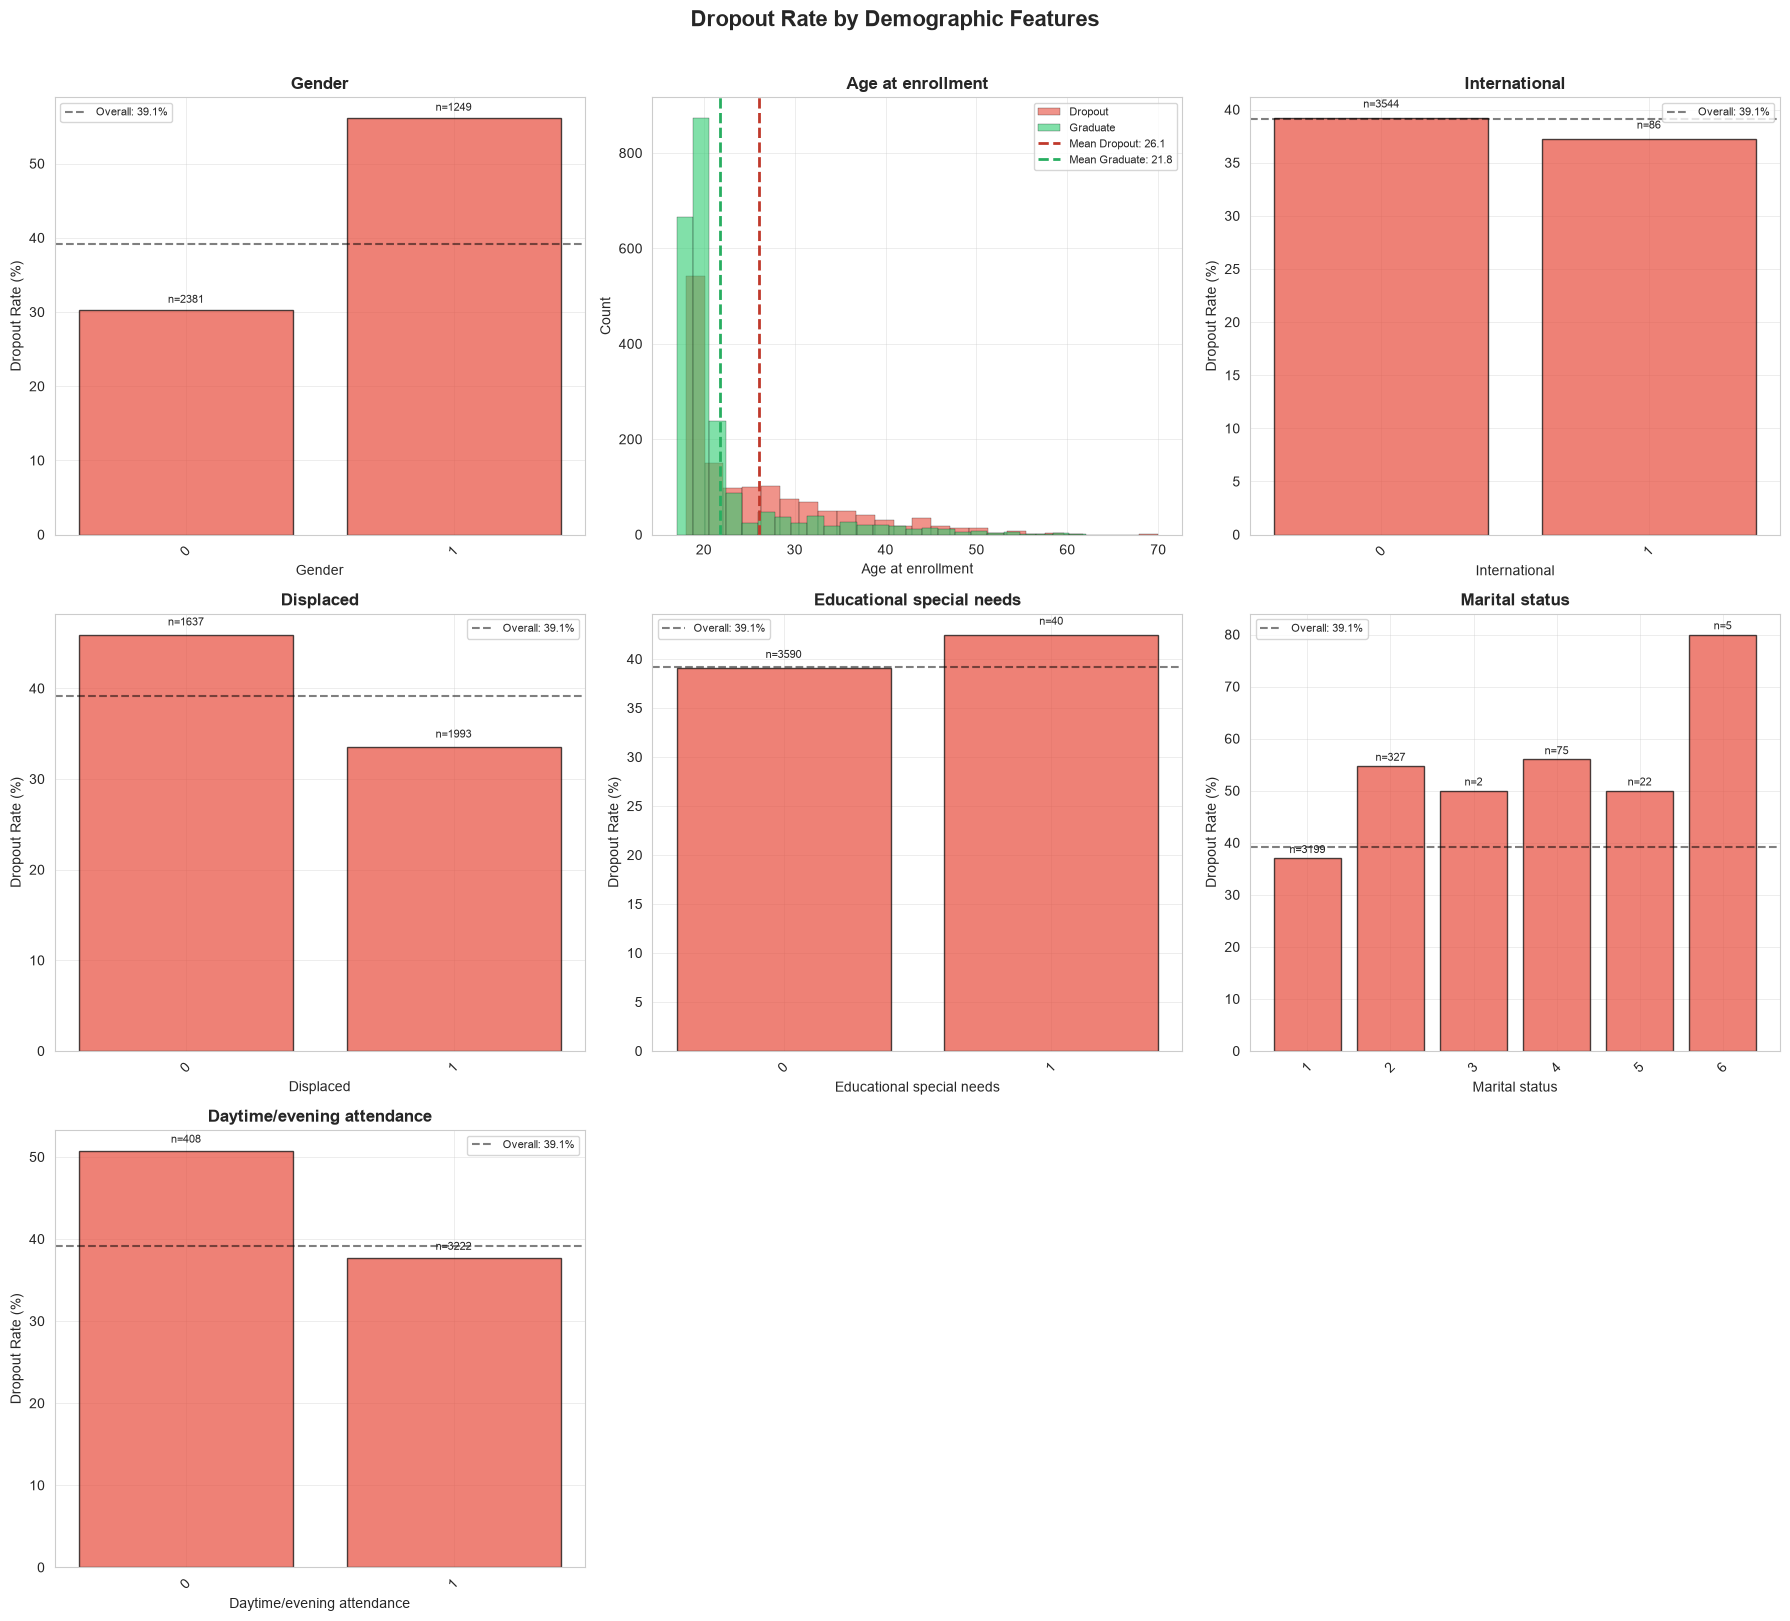

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(demographic_features):
    if i >= len(axes):
        break
    
    ax = axes[i]
    
    # Skip if column doesn't exist
    if col not in df_binary.columns:
        ax.text(0.5, 0.5,
                f"'{col}'\nnot found",
                ha='center', va='center',
                transform=ax.transAxes,
                fontsize=10,
                color='gray'
                )
        ax.set_title(col, fontweight='bold')
        continue
    
    if col == 'Age at enrollment':
        # Histogram for continuous variable
        for target, color in [('Dropout', '#e74c3c'), ('Graduate', '#2ecc71')]:
            subset = df_binary[df_binary['Target'] == target][col].dropna()
            ax.hist(subset,
                    bins=25, alpha=0.6, color=color,
                    label=target,
                   edgecolor='black',
                    linewidth=0.3
                    )
        
        dropout_mean = df_binary[df_binary['Target'] == 'Dropout'][col].mean()
        grad_mean = df_binary[df_binary['Target'] == 'Graduate'][col].mean()
        ax.axvline(dropout_mean,
                   color='#c0392b', linestyle='--', linewidth=2,
                   label=f"Mean Dropout: {dropout_mean:.1f}"
                   )
        ax.axvline(grad_mean,
                   color='#27ae60', linestyle='--', linewidth=2,
                   label=f"Mean Graduate: {grad_mean:.1f}"
                   )
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
    else:
        # Bar plot for categorical
        dropout_rates = df_binary.groupby(col)['Dropout_numeric'].mean() * 100
        counts = df_binary[col].value_counts()
        
        # Create DataFrame for plotting
        categories = [str(c) for c in dropout_rates.index]
        rates = dropout_rates.values
        cat_counts = [counts.get(idx, 0) for idx in dropout_rates.index]
        
        bars = ax.bar(categories, rates, color='#e74c3c', alpha=0.7, edgecolor='black')
        ax.axhline(y=df_binary['Dropout_numeric'].mean() * 100,
                  color='black', linestyle='--', alpha=0.5,
                  label=f"Overall: {df_binary['Dropout_numeric'].mean()*100:.1f}%")
        
        # Add count labels
        for bar, count in zip(bars, cat_counts):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                   f'n={count}', ha='center', fontsize=8)
        
        ax.set_xlabel(col)
        ax.set_ylabel('Dropout Rate (%)')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)
    
    ax.set_title(col, fontweight='bold')

# Hide unused subplots
for i in range(len(demographic_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Dropout Rate by Demographic Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/dropout_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Academic Performance Analysis

In [43]:
# Key academic features
academic_features = [
    'Previous qualification (grade)',
    'Admission grade',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (enrolled)'
]

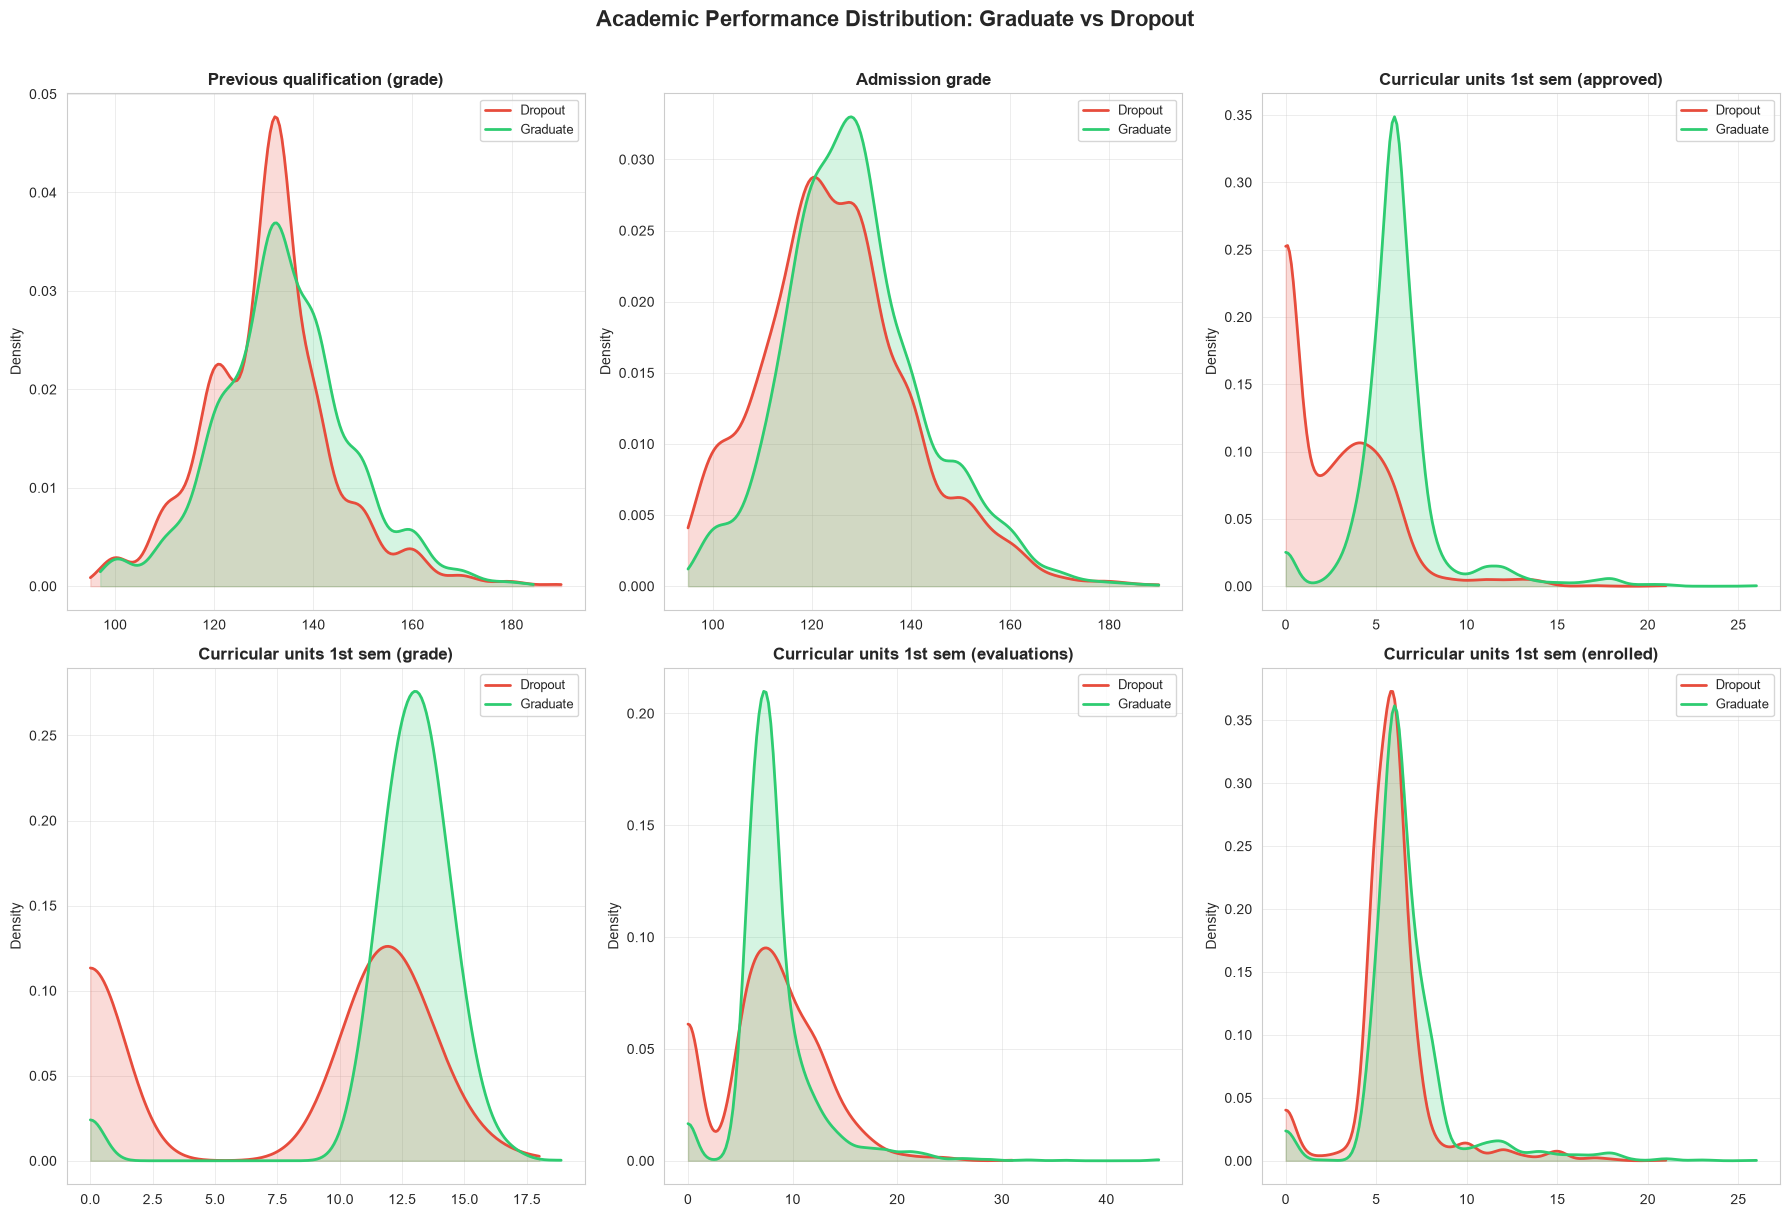


Statistical Summary (Mean ± Std) - Cohen's d Effect Size:
-------------------------------------------------------------------------------------
Feature                                       |         Dropout |        Graduate | Cohen's d
-------------------------------------------------------------------------------------
Previous qualification (grade)                | 131.11 ±12.87 | 134.08 ±13.34 | +0.23
Admission grade                               | 124.96 ±15.13 | 128.79 ±14.07 | +0.26
Curricular units 1st sem (approved)           |   2.55 ± 2.86 |   6.23 ± 2.58 | +1.35
Curricular units 1st sem (grade)              |   7.26 ± 6.03 |  12.64 ± 2.70 | +1.15
Curricular units 1st sem (evaluations)        |   7.75 ± 4.92 |   8.28 ± 3.81 | +0.12
Curricular units 1st sem (enrolled)           |   5.82 ± 2.33 |   6.67 ± 2.66 | +0.34


In [44]:
# Filter to only features that exist in the dataframe
academic_features = [f for f in academic_features if f in df_binary.columns]

if len(academic_features) > 0:
    n_cols = 3
    n_rows = (len(academic_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    axes = axes.flatten() if len(academic_features) > 1 else [axes]
    
    for i, col in enumerate(academic_features):
        ax = axes[i]
        
        for target, color in [('Dropout', '#e74c3c'), ('Graduate', '#2ecc71')]:
            data = df_binary[df_binary['Target'] == target][col].dropna()
            if len(data) > 1:
                try:
                    kde = gaussian_kde(data)
                    x_range = np.linspace(data.min(), data.max(), 200)
                    ax.plot(x_range, kde(x_range), color=color, linewidth=2, label=target)
                    ax.fill_between(x_range, kde(x_range), alpha=0.2, color=color)
                except Exception:
                    data.plot.kde(ax=ax, color=color, linewidth=2, label=target)
        
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
    
    # Hide unused subplots
    for i in range(len(academic_features), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Academic Performance Distribution: Graduate vs Dropout',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('../reports/figures/academic_performance_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Statistical comparison with Cohen's d
    print("\nStatistical Summary (Mean ± Std) - Cohen's d Effect Size:")
    print("-" * 85)
    print(f"{'Feature':<45s} | {'Dropout':>15s} | {'Graduate':>15s} | Cohen's d")
    print("-" * 85)
    
    for col in academic_features:
        drop_data = df_binary[df_binary['Target'] == 'Dropout'][col]
        grad_data = df_binary[df_binary['Target'] == 'Graduate'][col]
        
        d_mean = drop_data.mean()
        d_std = drop_data.std()
        g_mean = grad_data.mean()
        g_std = grad_data.std()
        
        pooled_std = np.sqrt((d_std**2 + g_std**2) / 2)
        cohens_d = (g_mean - d_mean) / pooled_std if pooled_std > 0 else 0
        
        # Truncate long column names
        display_col = col[:42] + '...' if len(col) > 45 else col
        print(f"{display_col:<45s} | {d_mean:6.2f} ±{d_std:5.2f} | {g_mean:6.2f} ±{g_std:5.2f} | {cohens_d:+.2f}")
else:
    print("-  No academic features found in dataframe")

## 2.5 Financial factors analysis

In [45]:
financial_features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder']

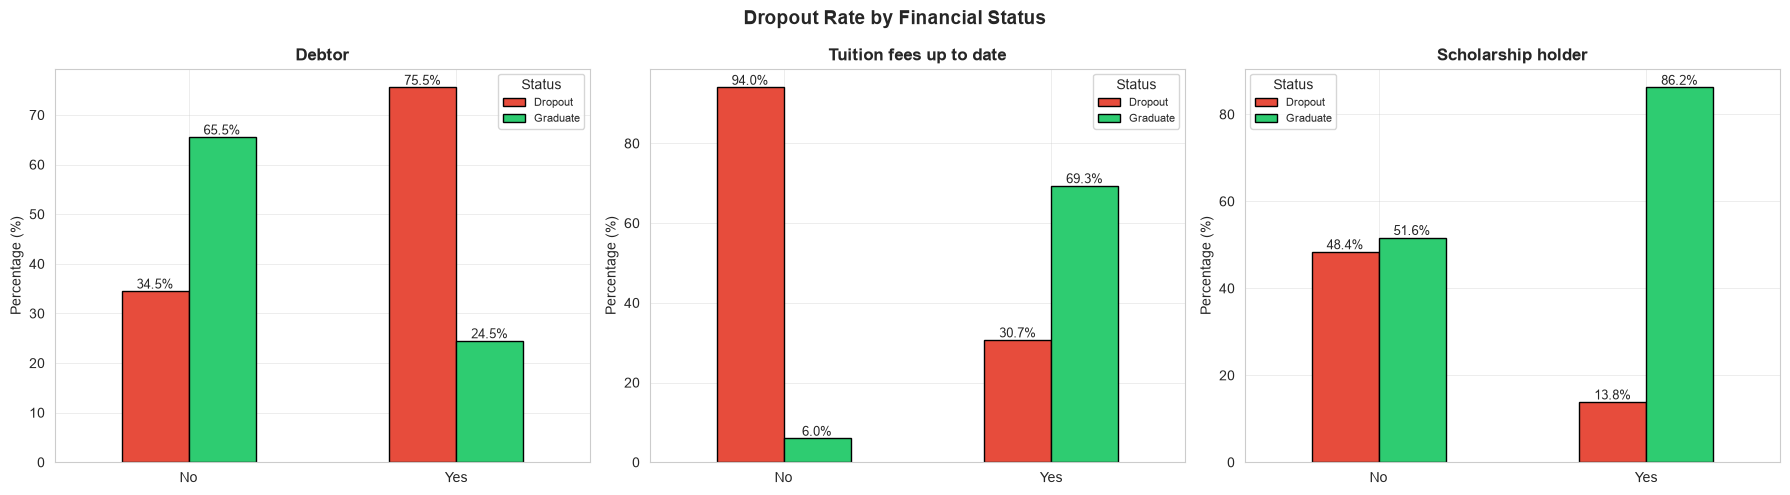


Dropout rate by Financial Stress Score:
----------------------------------------
  Stress Score 0: 10.5% dropout (n=877)
  Stress Score 1: 37.2% dropout (n=2150)
  Stress Score 2: 83.0% dropout (n=399)
  Stress Score 3: 97.1% dropout (n=204)


In [46]:
financial_features = [f for f in financial_features if f in df_binary.columns]

if len(financial_features) > 0:
    fig, axes = plt.subplots(1, len(financial_features), figsize=(6 * len(financial_features), 5))
    
    # Handle single subplot case
    if len(financial_features) == 1:
        axes = [axes]
    
    for i, col in enumerate(financial_features):
        ax = axes[i]
        
        # Calculate dropout rates with cross-tab
        cross_tab = pd.crosstab(df_binary[col], df_binary['Target'], normalize='index') * 100
        
        cross_tab.plot(kind='bar', ax=ax, color=TARGET_PALETTE_INVERSE, edgecolor='black')
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Percentage (%)')
        ax.legend(title='Status', fontsize=8)
        ax.set_xticklabels(['No', 'Yes'], rotation=0)
        
        # Add percentage labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', fontsize=9)
    
    plt.suptitle('Dropout Rate by Financial Status', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/dropout_by_financial.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Create composite financial stress score
    if all(f in df_binary.columns for f in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']):
        df_binary['financial_stress'] = (
            df_binary['Debtor'] + 
            (1 - df_binary['Tuition fees up to date']) + 
            (1 - df_binary['Scholarship holder'])
        )
        
        print("\nDropout rate by Financial Stress Score:")
        print("-" * 40)
        for score in sorted(df_binary['financial_stress'].dropna().unique()):
            subset = df_binary[df_binary['financial_stress'] == score]
            dropout_rate = subset['Dropout_numeric'].mean() * 100
            print(f"  Stress Score {int(score)}: {dropout_rate:.1f}% dropout (n={len(subset)})")
else:
    print("-  No financial features found in dataframe")

## 2.6 Semester-over-semester trajectory

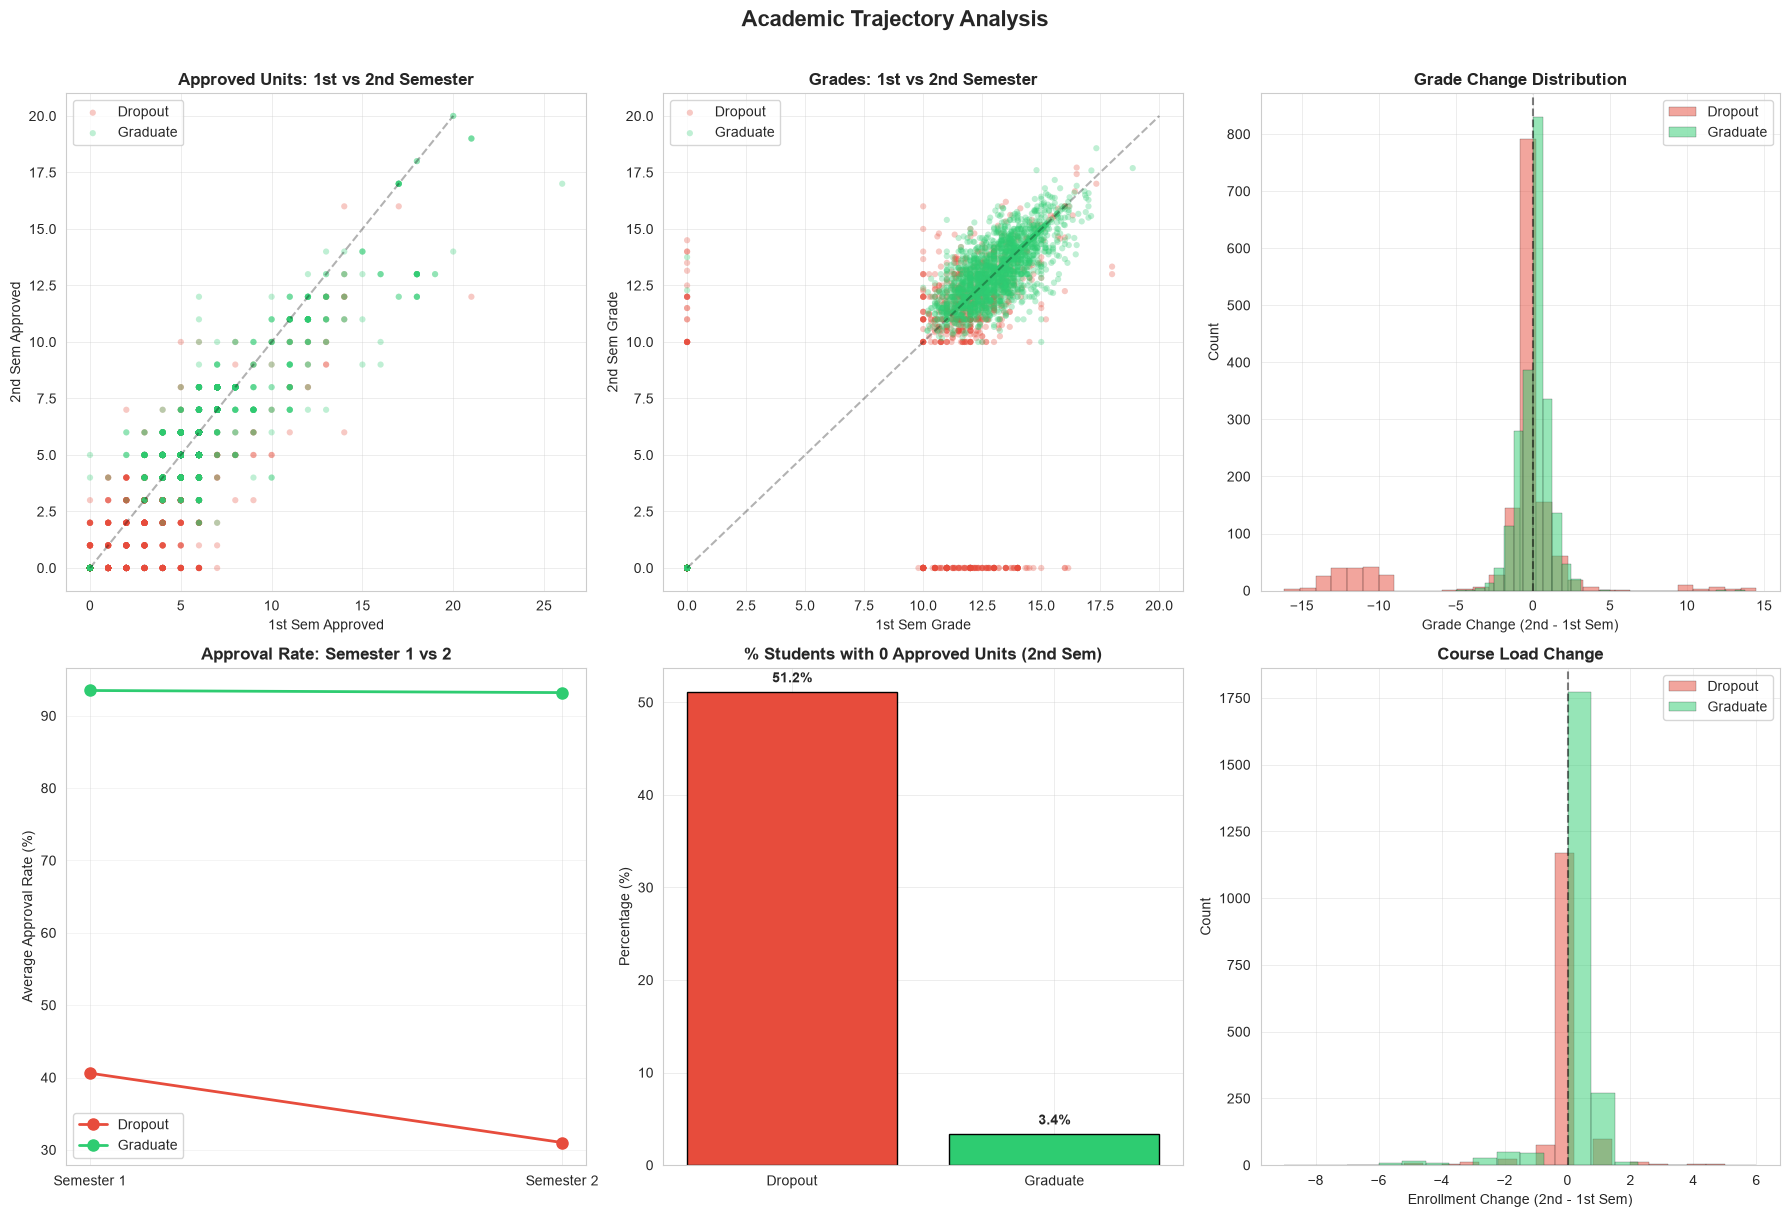

In [47]:
# Check if 2nd semester features exist
has_sem2 = any('2nd sem' in col for col in df_binary.columns)

if not has_sem2:
    print("-  2nd semester features not available. Skipping trajectory analysis.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Approved units comparison (scatter)
    ax = axes[0, 0]
    if all(c in df_binary.columns for c in ['Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)']):
        for target, color, marker in [('Dropout', '#e74c3c', 'o'), ('Graduate', '#2ecc71', 's')]:
            subset = df_binary[df_binary['Target'] == target]
            ax.scatter(subset['Curricular units 1st sem (approved)'],
                      subset['Curricular units 2nd sem (approved)'],
                      c=color, alpha=0.3, s=20, label=target, edgecolors='none')
        ax.plot([0, 20], [0, 20], 'k--', alpha=0.3)
        ax.set_xlabel('1st Sem Approved')
        ax.set_ylabel('2nd Sem Approved')
        ax.set_title('Approved Units: 1st vs 2nd Semester', fontweight='bold')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
    
    # Plot 2: Grade comparison (scatter)
    ax = axes[0, 1]
    if all(c in df_binary.columns for c in ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']):
        for target, color, marker in [('Dropout', '#e74c3c', 'o'), ('Graduate', '#2ecc71', 's')]:
            subset = df_binary[df_binary['Target'] == target]
            ax.scatter(subset['Curricular units 1st sem (grade)'],
                      subset['Curricular units 2nd sem (grade)'],
                      c=color, alpha=0.3, s=20, label=target, edgecolors='none')
        ax.plot([0, 20], [0, 20], 'k--', alpha=0.3)
        ax.set_xlabel('1st Sem Grade')
        ax.set_ylabel('2nd Sem Grade')
        ax.set_title('Grades: 1st vs 2nd Semester', fontweight='bold')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
    
    # Plot 3: Grade change histogram
    ax = axes[0, 2]
    if all(c in df_binary.columns for c in ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']):
        df_binary['grade_change'] = (df_binary['Curricular units 2nd sem (grade)'] -
                                      df_binary['Curricular units 1st sem (grade)'])
        for target, color in [('Dropout', '#e74c3c'), ('Graduate', '#2ecc71')]:
            subset = df_binary[df_binary['Target'] == target]['grade_change'].dropna()
            ax.hist(subset, bins=30, alpha=0.5, color=color, label=target, edgecolor='black', linewidth=0.3)
        ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Grade Change (2nd - 1st Sem)')
        ax.set_ylabel('Count')
        ax.set_title('Grade Change Distribution', fontweight='bold')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
    
    # Plot 4: Approval rate comparison (line plot)
    ax = axes[1, 0]
    if all(c in df_binary.columns for c in ['Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
                                               'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']):
        df_binary['approval_rate_sem1'] = (
            df_binary['Curricular units 1st sem (approved)'] / 
            df_binary['Curricular units 1st sem (enrolled)'].replace(0, np.nan)
        ) * 100
        df_binary['approval_rate_sem2'] = (
            df_binary['Curricular units 2nd sem (approved)'] / 
            df_binary['Curricular units 2nd sem (enrolled)'].replace(0, np.nan)
        ) * 100
        
        for target, color in [('Dropout', '#e74c3c'), ('Graduate', '#2ecc71')]:
            subset = df_binary[df_binary['Target'] == target]
            means = [subset['approval_rate_sem1'].mean(), subset['approval_rate_sem2'].mean()]
            ax.plot(['Semester 1', 'Semester 2'], means, marker='o', color=color,
                   linewidth=2, markersize=8, label=target)
        ax.set_ylabel('Average Approval Rate (%)')
        ax.set_title('Approval Rate: Semester 1 vs 2', fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
    
    # Plot 5: Students who passed 0 courses in 2nd sem
    ax = axes[1, 1]
    if 'Curricular units 2nd sem (approved)' in df_binary.columns:
        zero_passed = df_binary.groupby('Target')['Curricular units 2nd sem (approved)'].apply(
            lambda x: (x == 0).sum() / len(x) * 100)
        bars = ax.bar(zero_passed.index, zero_passed.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
        ax.set_ylabel('Percentage (%)')
        ax.set_title('% Students with 0 Approved Units (2nd Sem)', fontweight='bold')
        for bar, val in zip(bars, zero_passed.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{val:.1f}%', ha='center', fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
    
    # Plot 6: Course load change
    ax = axes[1, 2]
    if all(c in df_binary.columns for c in ['Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (enrolled)']):
        df_binary['enrollment_change'] = (df_binary['Curricular units 2nd sem (enrolled)'] -
                                          df_binary['Curricular units 1st sem (enrolled)'])
        for target, color in [('Dropout', '#e74c3c'), ('Graduate', '#2ecc71')]:
            subset = df_binary[df_binary['Target'] == target]['enrollment_change'].dropna()
            ax.hist(subset, bins=20, alpha=0.5, color=color, label=target, edgecolor='black', linewidth=0.3)
        ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Enrollment Change (2nd - 1st Sem)')
        ax.set_ylabel('Count')
        ax.set_title('Course Load Change', fontweight='bold')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
    
    plt.suptitle('Academic Trajectory Analysis', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('../reports/figures/academic_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.7 Economic indicators analysis

In [48]:
economic_features = ['Unemployment rate', 'Inflation rate', 'GDP']

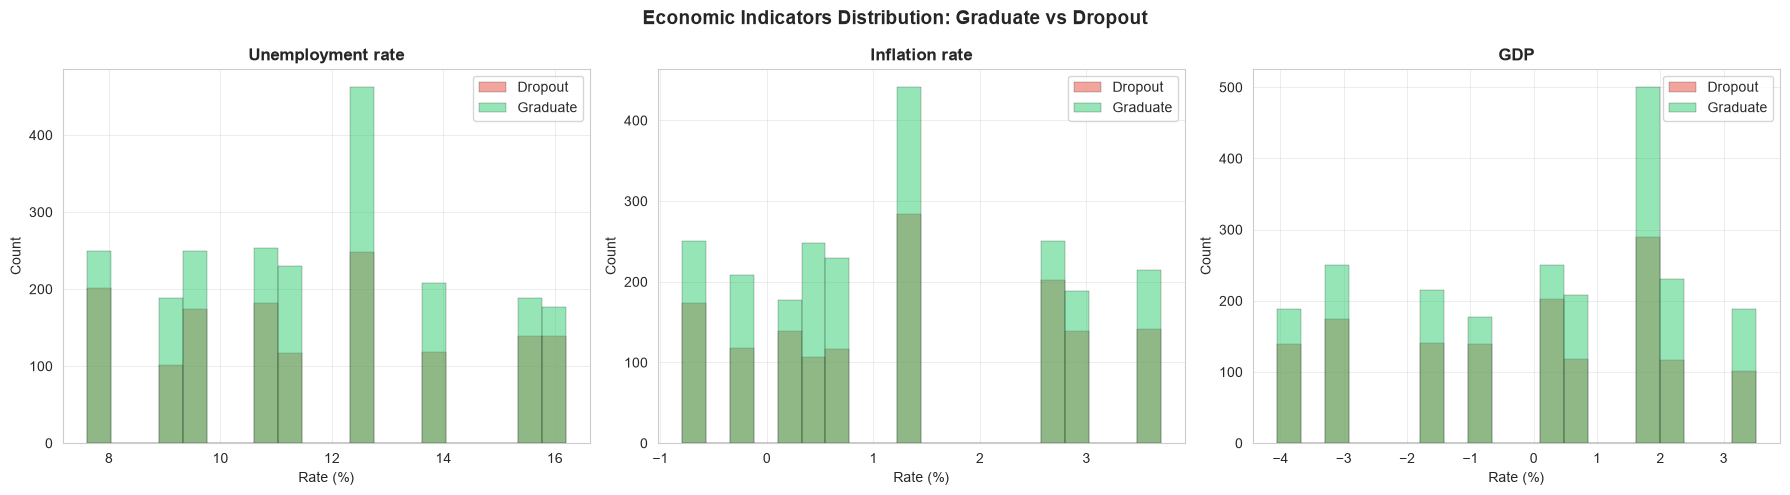


Economic Indicators Summary:
--------------------------------------------------
Unemployment rate         | Dropout: 11.62%  |  Graduate: 11.64%
Inflation rate            | Dropout: 1.28%  |  Graduate: 1.20%
GDP                       | Dropout: -0.15%  |  Graduate: 0.08%


In [49]:
economic_features = [f for f in economic_features if f in df_binary.columns]

if len(economic_features) > 0:
    fig, axes = plt.subplots(1, len(economic_features), figsize=(6 * len(economic_features), 5))
    
    if len(economic_features) == 1:
        axes = [axes]
    
    for i, col in enumerate(economic_features):
        ax = axes[i]
        
        for target, color in [('Dropout', '#e74c3c'), ('Graduate', '#2ecc71')]:
            subset = df_binary[df_binary['Target'] == target][col].dropna()
            ax.hist(subset, bins=20, alpha=0.5, color=color, label=target, 
                   edgecolor='black', linewidth=0.3)
        
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('Rate (%)')
        ax.set_ylabel('Count')
        ax.legend()
    
    plt.suptitle('Economic Indicators Distribution: Graduate vs Dropout', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/economic_indicators.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Summary statistics
    print("\nEconomic Indicators Summary:")
    print("-" * 50)
    for col in economic_features:
        d_mean = df_binary[df_binary['Target'] == 'Dropout'][col].mean()
        g_mean = df_binary[df_binary['Target'] == 'Graduate'][col].mean()
        print(f"{col:25s} | Dropout: {d_mean:.2f}%  |  Graduate: {g_mean:.2f}%")
else:
    print("-  No economic features found in dataframe")

## 2.8 Correlation analysis


Top 15 Features Positively Correlated with Dropout (Risk Factors):
----------------------------------------------------------------------
  financial_stress                                      | +0.493 ████████████████████████
  Age at enrollment                                     | +0.267 █████████████
  Debtor                                                | +0.267 █████████████
  Gender                                                | +0.252 ████████████
  Curricular units 2nd sem (without evaluations)        | +0.103 █████
  Curricular units 1st sem (without evaluations)        | +0.075 ███
  Mother's qualification                                | +0.054 ██
  Inflation rate                                        | +0.030 █
  Educational special needs                             | +0.007 
  Father's qualification                                | +0.006 
  enrollment_change                                     | +0.000 
  Unemployment rate                                     | -0.0

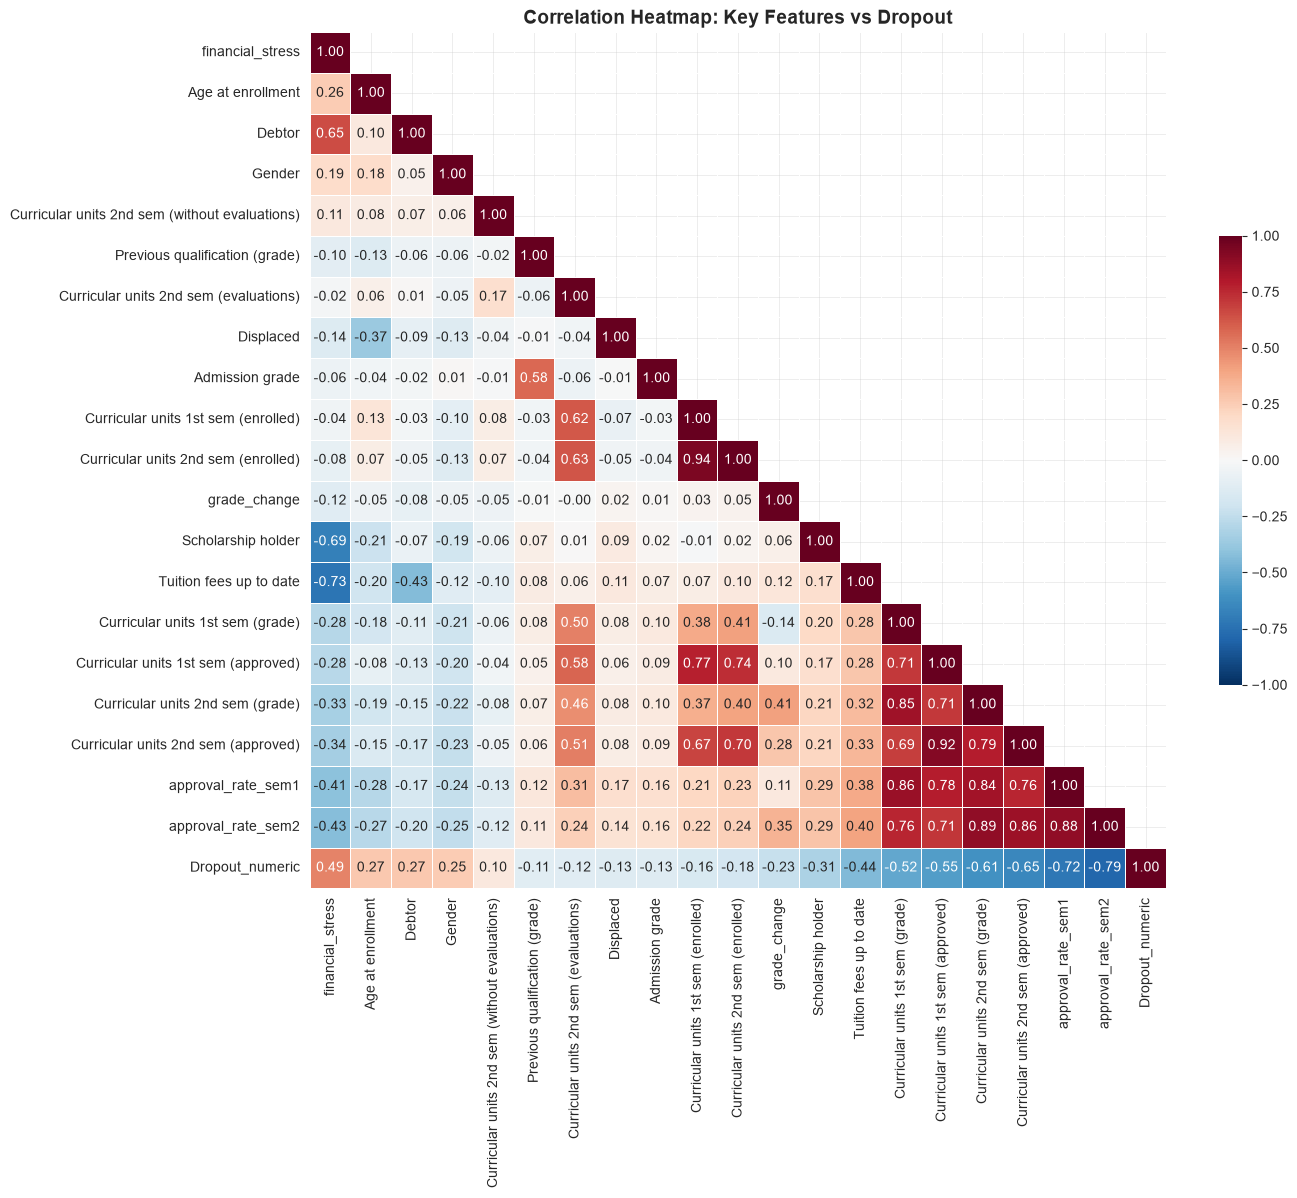

In [50]:
# Select numeric columns only
numeric_cols = df_binary.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Dropout_numeric']

if len(numeric_cols) > 0:
    # Calculate correlations with dropout
    correlations = df_binary[numeric_cols + ['Dropout_numeric']].corr()['Dropout_numeric'].drop('Dropout_numeric')
    correlations = correlations.sort_values(ascending=False)
    
    # Display top positive correlations (risk factors)
    print("\nTop 15 Features Positively Correlated with Dropout (Risk Factors):")
    print("-" * 70)
    for feat, corr in correlations.head(15).items():
        bar_len = int(abs(corr) * 50)
        bar = '█' * bar_len
        # Truncate long names
        display_feat = feat[:50] + '...' if len(feat) > 53 else feat
        print(f"  {display_feat:<53s} | {corr:+.3f} {bar}")
    
    print("\nTop 15 Features Negatively Correlated with Dropout (Protective Factors):")
    print("-" * 70)
    for feat, corr in correlations.tail(15).items():
        bar_len = int(abs(corr) * 50)
        bar = '█' * bar_len
        display_feat = feat[:50] + '...' if len(feat) > 53 else feat
        print(f"  {display_feat:<53s} | {corr:+.3f} {bar}")
    
    # Correlation heatmap (top features with |corr| > 0.1)
    top_features = correlations[abs(correlations) > 0.1].index.tolist()
    
    if len(top_features) > 1:
        plt.figure(figsize=(14, 12))
        
        corr_matrix = df_binary[top_features + ['Dropout_numeric']].corr()
        
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        
        sns.heatmap(
            corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.5}
        )
        
        plt.title('Correlation Heatmap: Key Features vs Dropout', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("\n-  No features with |correlation| > 0.1 to display in heatmap")
else:
    print("-  No numeric columns found for correlation analysis")

## 2.9 Course-level analysis


Top 10 Courses by Dropout Rate:


,Course,Total_Students,Dropout_Rate,Avg_Grade_Sem1,Avg_Admission_Grade
1,33,9,88.889,8.496,116.522
6,9119,106,86.792,7.395,124.848
7,9130,120,65.000,9.651,132.733
16,9991,214,63.551,8.657,129.879
15,9853,142,59.859,11.111,123.832
3,9003,173,49.711,10.323,132.593
8,9147,272,49.265,9.819,123.421
12,9556,69,47.826,10.650,122.451
0,171,178,46.067,1.868,136.484
10,9254,211,45.498,10.203,121.498



Bottom 10 Courses (Lowest Dropout):


,Course,Total_Students,Dropout_Rate,Avg_Grade_Sem1,Avg_Admission_Grade
11,9500,666,17.718,12.485,127.947
9,9238,313,20.767,11.321,125.908
4,9070,184,27.717,12.136,129.568
14,9773,297,34.007,11.660,128.298
5,9085,262,34.351,11.807,131.685
2,8014,194,36.598,10.416,122.836
13,9670,220,43.182,11.125,121.370
10,9254,211,45.498,10.203,121.498
0,171,178,46.067,1.868,136.484
12,9556,69,47.826,10.650,122.451


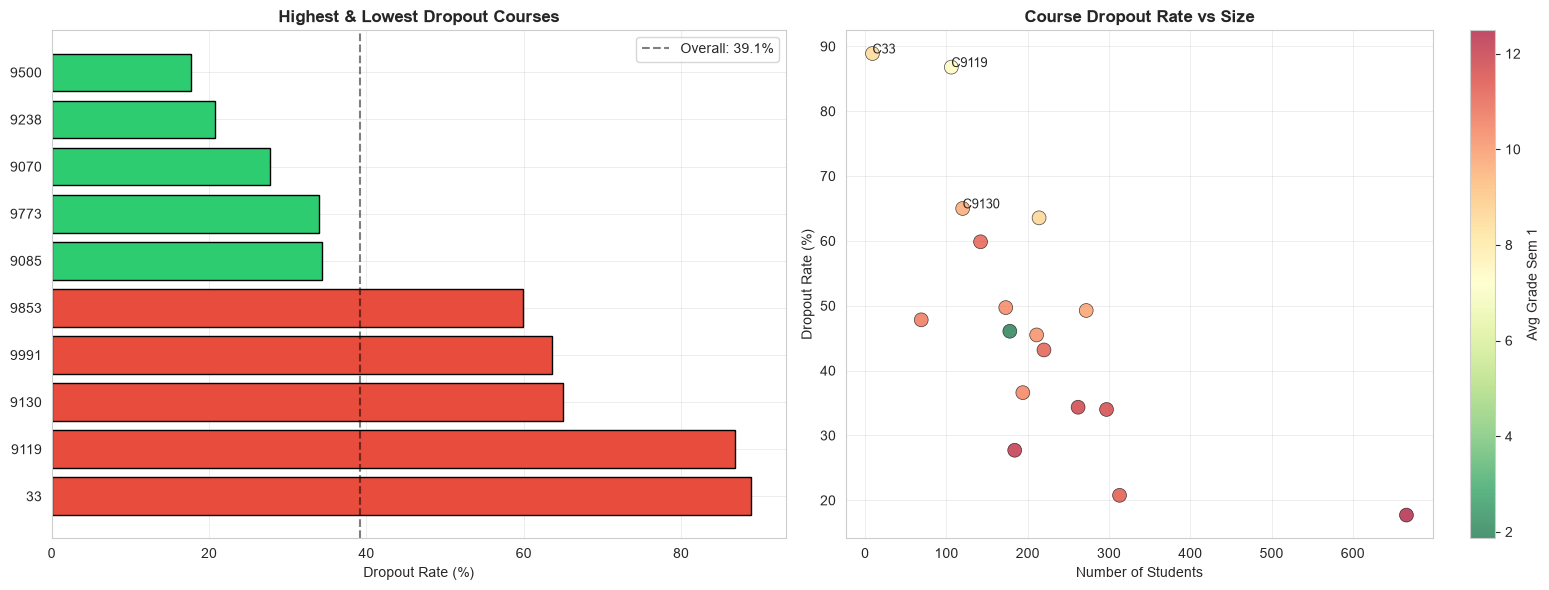

In [51]:
if 'Course' in df_binary.columns:
    # Calculate dropout rate per course
    course_stats = df_binary.groupby('Course').agg(
        Total_Students=('Dropout_numeric', 'count'),
        Dropout_Rate=('Dropout_numeric', 'mean'),
        Avg_Grade_Sem1=('Curricular units 1st sem (grade)', 'mean'),
        Avg_Admission_Grade=('Admission grade', 'mean')
    ).reset_index()
    
    course_stats['Dropout_Rate'] = course_stats['Dropout_Rate'] * 100
    course_stats = course_stats.sort_values('Dropout_Rate', ascending=False)
    
    print("\nTop 10 Courses by Dropout Rate:")
    display(course_stats.head(10))
    
    print("\nBottom 10 Courses (Lowest Dropout):")
    display(course_stats.tail(10).sort_values('Dropout_Rate'))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot of top/bottom courses
    ax = axes[0]
    plot_courses = pd.concat([course_stats.head(5), course_stats.tail(5)])
    overall_rate = df_binary['Dropout_numeric'].mean() * 100
    colors_plot = ['#e74c3c' if x > overall_rate else '#2ecc71' for x in plot_courses['Dropout_Rate']]
    
    bars = ax.barh(plot_courses['Course'].astype(str), plot_courses['Dropout_Rate'],
                   color=colors_plot, edgecolor='black')
    ax.axvline(x=overall_rate, color='black', linestyle='--', alpha=0.5,
              label=f"Overall: {overall_rate:.1f}%")
    ax.set_xlabel('Dropout Rate (%)')
    ax.set_title('Highest & Lowest Dropout Courses', fontweight='bold')
    ax.legend()
    
    # Scatter: Students vs Dropout Rate
    ax = axes[1]
    scatter = ax.scatter(
        course_stats['Total_Students'], 
        course_stats['Dropout_Rate'],
        c=course_stats['Avg_Grade_Sem1'], 
        cmap='RdYlGn_r',
        s=100, 
        edgecolors='black', 
        linewidth=0.5, 
        alpha=0.7
    )
    ax.set_xlabel('Number of Students')
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_title('Course Dropout Rate vs Size', fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Avg Grade Sem 1')
    
    # Add labels for extreme courses
    for _, row in course_stats.head(3).iterrows():
        ax.annotate(f"C{int(row['Course'])}",
                   (row['Total_Students'], row['Dropout_Rate']),
                   fontsize=9, ha='left')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/dropout_by_course.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("-  'Course' column not found in dataframe")

## 1.10 Multivariate analysis - pair plot

In [52]:
# Select key features for pair plot
pair_features = [
    'Admission grade',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (enrolled)'
]

# Add 2nd semester features if available
if 'Curricular units 2nd sem (approved)' in df_binary.columns:
    pair_features.append('Curricular units 2nd sem (approved)')
if 'Curricular units 2nd sem (grade)' in df_binary.columns:
    pair_features.append('Curricular units 2nd sem (grade)')

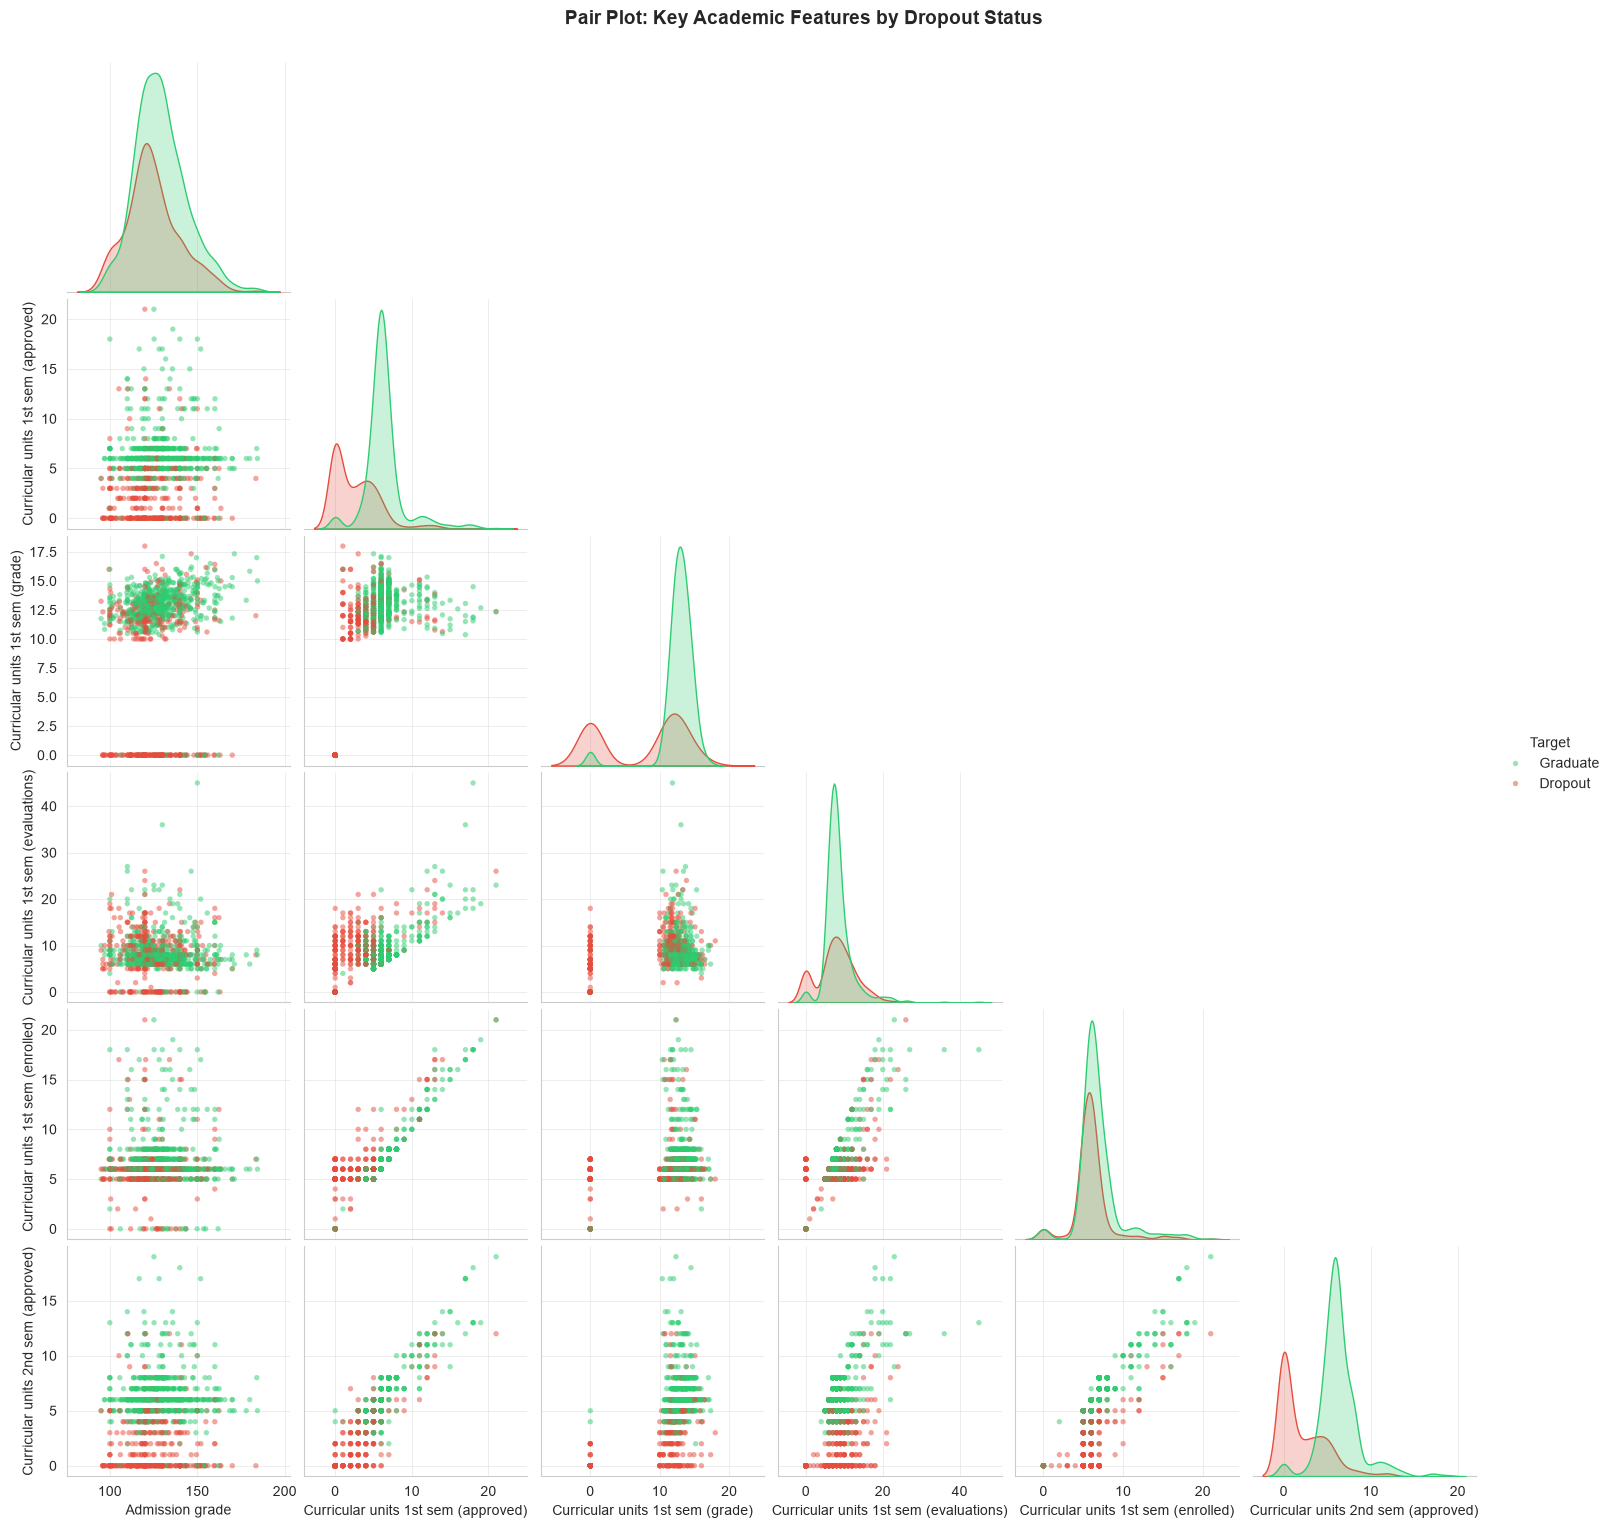

In [53]:
# Filter to existing columns
pair_features = [f for f in pair_features if f in df_binary.columns]

if len(pair_features) >= 2:
    # Sample to avoid overcrowding
    sample_size = min(1000, len(df_binary))
    df_sample = df_binary.sample(n=sample_size, random_state=42)
    
    # Create pair plot (corner only for clarity)
    g = sns.pairplot(
        df_sample,
        vars=pair_features[:6],  # Limit to 6 features for readability
        hue='Target',
        palette=TARGET_COLORS,
        diag_kind='kde',
        plot_kws={'alpha': 0.5, 's': 15, 'edgecolor': 'none'},
        corner=True
    )
    
    g.figure.suptitle('Pair Plot: Key Academic Features by Dropout Status', fontsize=14, fontweight='bold', y=1.02)
    plt.savefig('../reports/figures/pair_plot_academic.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("-  Not enough features for pair plot (need at least 2)")

## 2.11 Chi-square test for categorical features

In [54]:
categorical_features = [
    'Gender', 'Scholarship holder', 'Debtor',
    'Tuition fees up to date', 'Displaced',
    'Educational special needs', 'International',
    'Daytime/evening attendance'
]


Chi-Square Test Results:


,Feature,Chi2,P-Value,Degrees of Freedom,Significant (p<0.05)
3,Tuition fees up to date,706.955,0.000,1,Yes
1,Scholarship holder,354.219,0.000,1,Yes
2,Debtor,257.460,0.000,1,Yes
0,Gender,229.352,0.000,1,Yes
4,Displaced,57.215,0.000,1,Yes
7,Daytime/evening attendance,25.371,0.000,1,Yes
5,Educational special needs,0.075,0.784,1,No
6,International,0.068,0.794,1,No


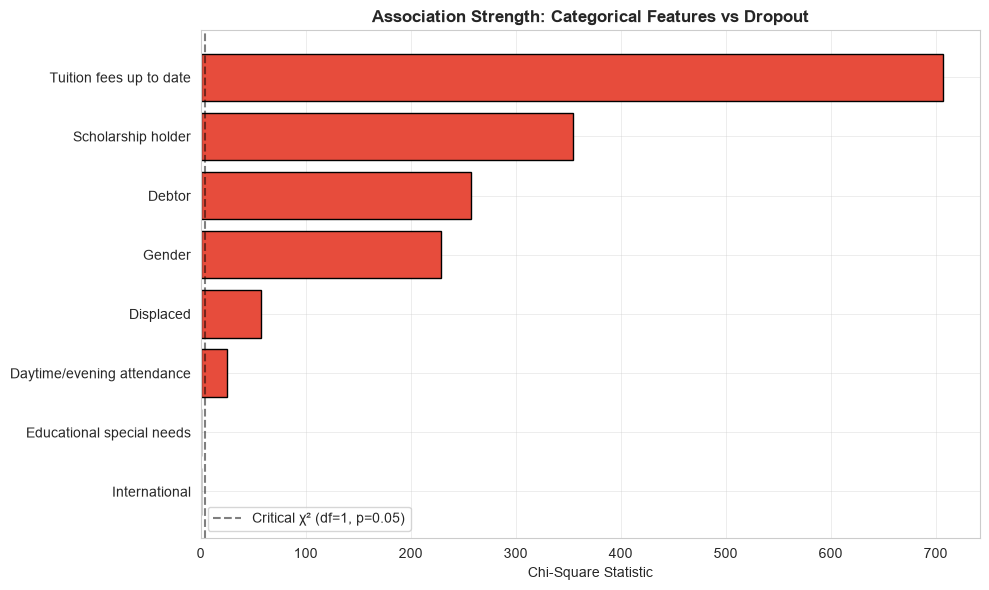

In [55]:
# Filter to existing columns
categorical_features = [f for f in categorical_features if f in df_binary.columns]

if len(categorical_features) > 0:
    chi2_results = []
    
    for col in categorical_features:
        # Create contingency table
        contingency = pd.crosstab(df_binary[col], df_binary['Target'])
        
        # Skip if contingency table is invalid
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue
        
        try:
            # Chi-square test
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            
            chi2_results.append({
                'Feature': col,
                'Chi2': chi2,
                'P-Value': p_value,
                'Degrees of Freedom': dof,
                'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
            })
        except Exception as e:
            print(f"-   Could not compute chi-square for '{col}': {e}")
    
    if len(chi2_results) > 0:
        chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
        print("\nChi-Square Test Results:")
        display(chi2_df)
        
        # Visualize
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in chi2_df['P-Value']]
        ax.barh(chi2_df['Feature'], chi2_df['Chi2'], color=colors, edgecolor='black')
        ax.axvline(x=3.84, color='black', linestyle='--', alpha=0.5, label='Critical χ² (df=1, p=0.05)')
        ax.set_xlabel('Chi-Square Statistic')
        ax.set_title('Association Strength: Categorical Features vs Dropout', fontweight='bold')
        ax.legend()
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("-  No valid chi-square tests computed")
else:
    print("-  No categorical features found")

## 1.12 Summary dashboard

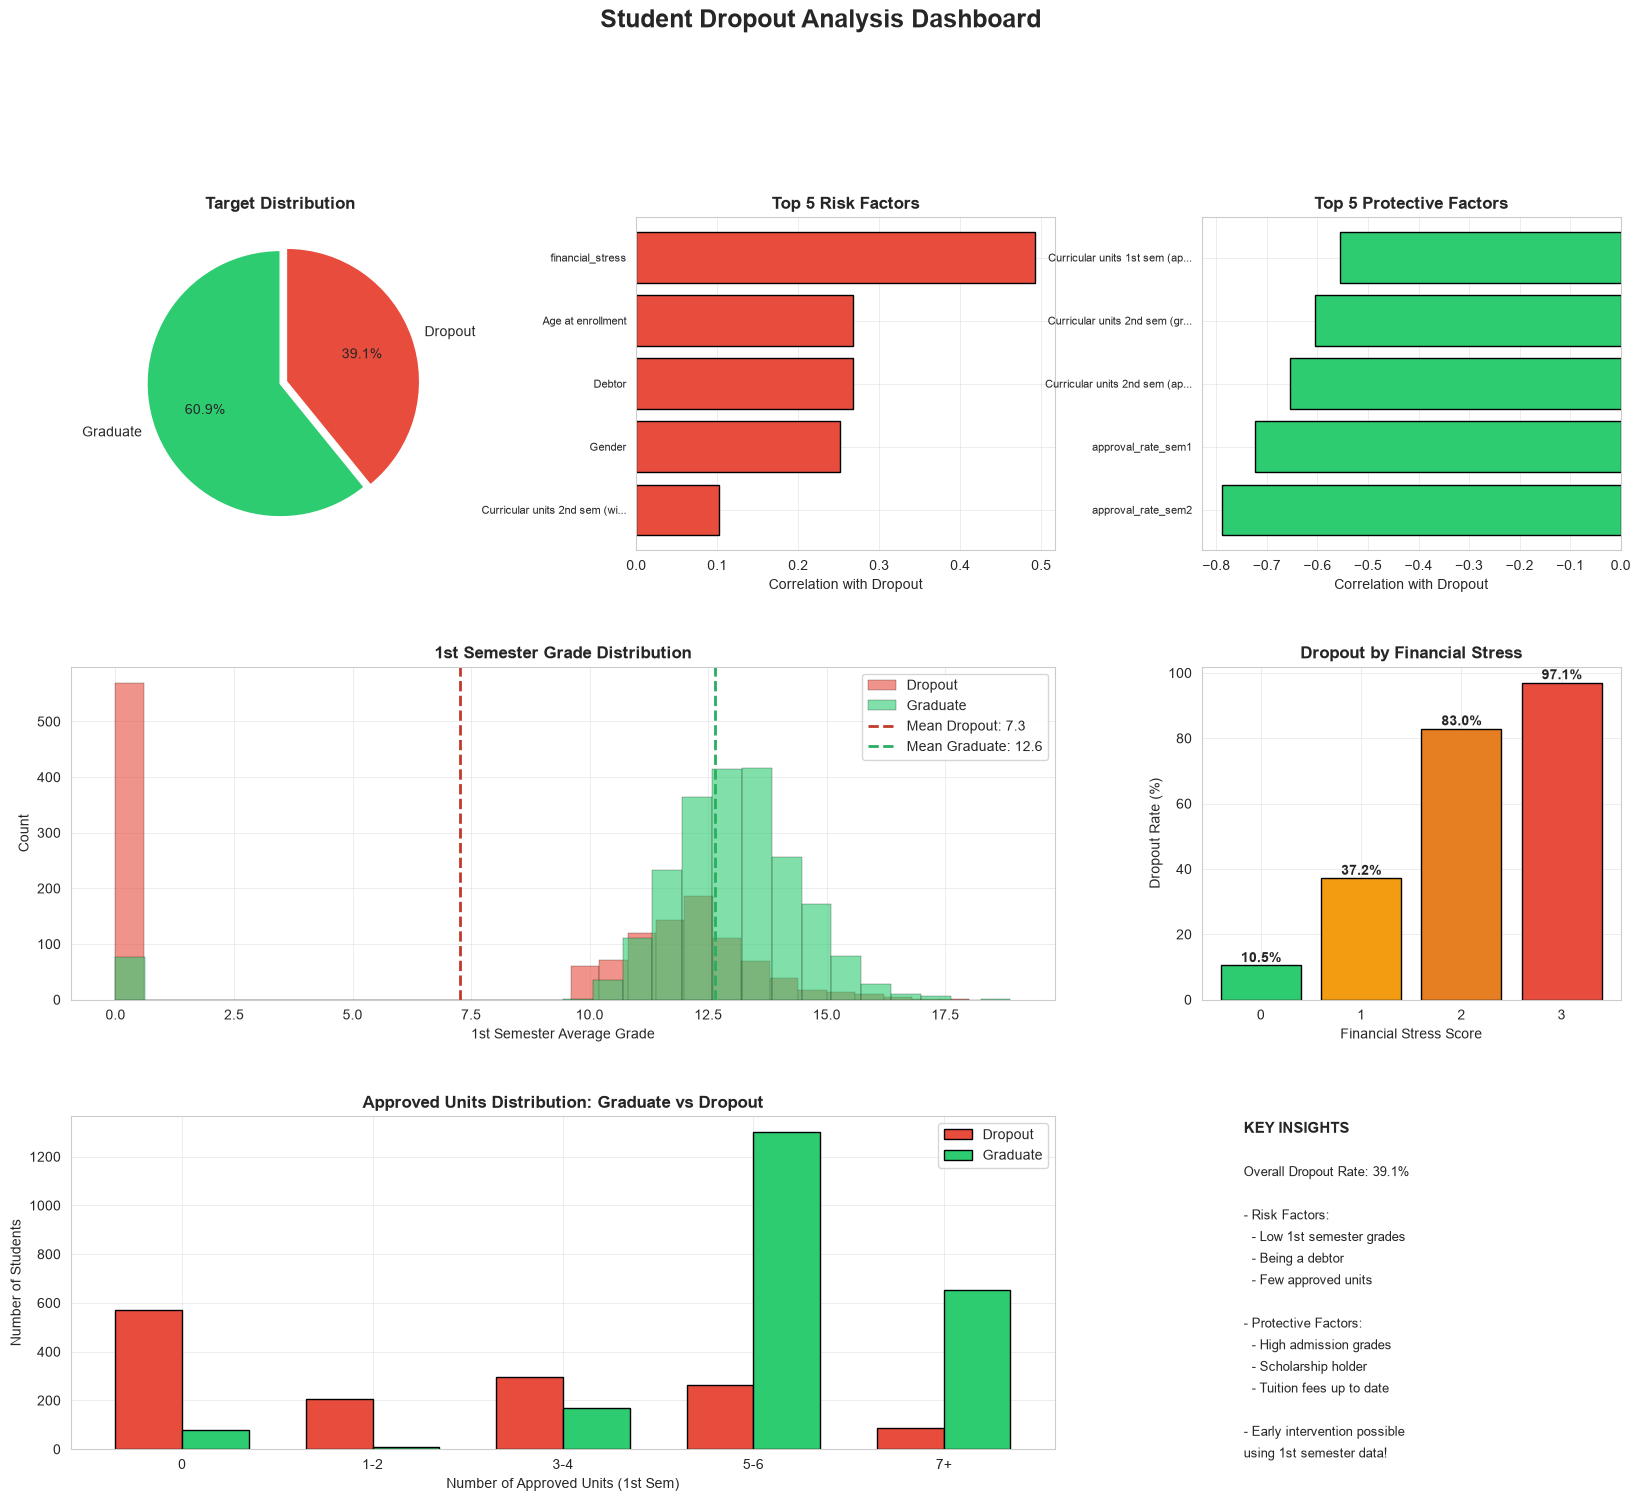

In [56]:
fig, _ = plt.subplots(figsize=(20.0, 16.0))
_.set_visible(False)  # Hide the empty subplot created by plt.subplots

gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 1. Target Distribution (pie chart)
ax1 = fig.add_subplot(gs[0, 0])
target_counts = df_binary['Target'].value_counts()
ax1.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.05),
        textprops={'fontsize': 10})
ax1.set_title('Target Distribution', fontweight='bold', fontsize=12)

# 2. Top 5 Risk Factors (positive correlation)
ax2 = fig.add_subplot(gs[0, 1])
if len(numeric_cols) > 0:
    correlations = df_binary[numeric_cols + ['Dropout_numeric']].corr()['Dropout_numeric'].drop('Dropout_numeric')
    correlations = correlations.sort_values(ascending=False)
    top_risk = correlations.head(5)
    
    ax2.barh(range(len(top_risk)), top_risk.values, color='#e74c3c', edgecolor='black')
    ax2.set_yticks(range(len(top_risk)))
    labels = [f[:28] + '...' if len(f) > 31 else f for f in top_risk.index]
    ax2.set_yticklabels(labels, fontsize=8)
    ax2.set_xlabel('Correlation with Dropout')
    ax2.set_title('Top 5 Risk Factors', fontweight='bold', fontsize=12)
    ax2.invert_yaxis()
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)

# 3. Top 5 Protective Factors (negative correlation)
ax3 = fig.add_subplot(gs[0, 2])
if len(numeric_cols) > 0:
    top_protective = correlations.tail(5)
    ax3.barh(range(len(top_protective)), top_protective.values, color='#2ecc71', edgecolor='black')
    ax3.set_yticks(range(len(top_protective)))
    labels = [f[:28] + '...' if len(f) > 31 else f for f in top_protective.index]
    ax3.set_yticklabels(labels, fontsize=8)
    ax3.set_xlabel('Correlation with Dropout')
    ax3.set_title('Top 5 Protective Factors', fontweight='bold', fontsize=12)
    ax3.invert_yaxis()
else:
    ax3.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax3.transAxes)

# 4. Grade Distribution by Target
ax4 = fig.add_subplot(gs[1, :2])
if 'Curricular units 1st sem (grade)' in df_binary.columns:
    for target, color in [('Dropout', '#e74c3c'), ('Graduate', '#2ecc71')]:
        subset = df_binary[df_binary['Target'] == target]['Curricular units 1st sem (grade)'].dropna()
        ax4.hist(subset, bins=30, alpha=0.6, color=color, label=target, edgecolor='black', linewidth=0.3)
    
    dropout_mean = df_binary[df_binary['Target'] == 'Dropout']['Curricular units 1st sem (grade)'].mean()
    grad_mean = df_binary[df_binary['Target'] == 'Graduate']['Curricular units 1st sem (grade)'].mean()
    ax4.axvline(dropout_mean, color='#c0392b', linestyle='--', linewidth=2,
               label=f'Mean Dropout: {dropout_mean:.1f}')
    ax4.axvline(grad_mean, color='#27ae60', linestyle='--', linewidth=2,
               label=f'Mean Graduate: {grad_mean:.1f}')
    ax4.set_xlabel('1st Semester Average Grade')
    ax4.set_ylabel('Count')
    ax4.set_title('1st Semester Grade Distribution', fontweight='bold', fontsize=12)
    ax4.legend()
else:
    ax4.text(0.5, 0.5, 'Grade data not available', ha='center', va='center', transform=ax4.transAxes)

# 5. Financial Stress Score
ax5 = fig.add_subplot(gs[1, 2])
if 'financial_stress' in df_binary.columns:
    stress_dropout = df_binary.groupby('financial_stress')['Dropout_numeric'].mean() * 100
    stress_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
    ax5.bar(stress_dropout.index.astype(int).astype(str), stress_dropout.values,
            color=stress_colors[:len(stress_dropout)], edgecolor='black')
    ax5.set_xlabel('Financial Stress Score')
    ax5.set_ylabel('Dropout Rate (%)')
    ax5.set_title('Dropout by Financial Stress', fontweight='bold', fontsize=12)
    # Add value labels
    for i, v in enumerate(stress_dropout.values):
        ax5.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
else:
    ax5.text(0.5, 0.5, 'Financial data\nnot available', ha='center', va='center',
            transform=ax5.transAxes, fontsize=12, color='gray')

# 6. Approved Units Distribution
ax6 = fig.add_subplot(gs[2, :2])
if 'Curricular units 1st sem (approved)' in df_binary.columns:
    labels = ['0', '1-2', '3-4', '5-6', '7+']
    bins = [-1, 0, 2, 4, 6, 20]
    
    dropout_binned = pd.cut(
        df_binary[df_binary['Target'] == 'Dropout']['Curricular units 1st sem (approved)'],
        bins=bins, labels=labels
    ).value_counts().sort_index()
    
    grad_binned = pd.cut(
        df_binary[df_binary['Target'] == 'Graduate']['Curricular units 1st sem (approved)'],
        bins=bins, labels=labels
    ).value_counts().sort_index()
    
    x = np.arange(len(labels))
    width = 0.35
    ax6.bar(x - width/2, dropout_binned.values, width, label='Dropout', 
            color='#e74c3c', edgecolor='black')
    ax6.bar(x + width/2, grad_binned.values, width, label='Graduate', 
            color='#2ecc71', edgecolor='black')
    ax6.set_xlabel('Number of Approved Units (1st Sem)')
    ax6.set_ylabel('Number of Students')
    ax6.set_title('Approved Units Distribution: Graduate vs Dropout', fontweight='bold', fontsize=12)
    ax6.set_xticks(x)
    ax6.set_xticklabels(labels)
    ax6.legend()
else:
    ax6.text(0.5, 0.5, 'Approved units data not available', ha='center', va='center',
            transform=ax6.transAxes, fontsize=12, color='gray')

# 7. Key Insights Text Box
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
dropout_rate = df_binary['Dropout_numeric'].mean() * 100
insights = [
    "KEY INSIGHTS",
    "",
    f"Overall Dropout Rate: {dropout_rate:.1f}%",
    "",
    "- Risk Factors:",
    "  - Low 1st semester grades",
    "  - Being a debtor",
    "  - Few approved units",
    "",
    "- Protective Factors:",
    "  - High admission grades",
    "  - Scholarship holder",
    "  - Tuition fees up to date",
    "",
    "- Early intervention possible",
    "using 1st semester data!"
]
for i, line in enumerate(insights):
    y_pos = 0.95 - i * 0.065
    fontweight = 'bold' if i == 0 else 'normal'
    fontsize = 11 if i == 0 else 9
    ax7.text(0.1, y_pos, line, transform=ax7.transAxes,
            fontsize=fontsize, fontweight=fontweight)

plt.suptitle('Student Dropout Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.savefig('../reports/figures/eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.13 Key findings

:TODO

## Save keys statistics for modeling

In [57]:
# Save the correlation results for feature selection
if len(numeric_cols) > 0:
    correlations.to_csv('../data/processed/feature_correlations.csv')
    print("- Feature correlations saved to ../data/processed/feature_correlations.csv")

# Save the binary dataset for next notebook
df_binary.to_pickle('../data/processed/df_binary_eda.pkl')
print("- Binary dataframe saved to ../data/processed/df_binary_eda.pkl")

# Print final column list
print(f"\nFinal columns ({len(df_binary.columns)}):")
for i, col in enumerate(df_binary.columns, 1):
    print(f"  {i:2d}. {col} ({df_binary[col].dtype})")

- Feature correlations saved to ../data/processed/feature_correlations.csv
- Binary dataframe saved to ../data/processed/df_binary_eda.pkl

Final columns (43):
   1. Marital status (object)
   2. Application mode (object)
   3. Application order (object)
   4. Course (object)
   5. Daytime/evening attendance (int64)
   6. Previous qualification (object)
   7. Previous qualification (grade) (float64)
   8. Nacionality (object)
   9. Mother's qualification (int64)
  10. Father's qualification (int64)
  11. Mother's occupation (object)
  12. Father's occupation (object)
  13. Admission grade (float64)
  14. Displaced (int64)
  15. Educational special needs (int64)
  16. Debtor (int64)
  17. Tuition fees up to date (int64)
  18. Gender (int64)
  19. Scholarship holder (int64)
  20. Age at enrollment (float64)
  21. International (int64)
  22. Curricular units 1st sem (credited) (float64)
  23. Curricular units 1st sem (enrolled) (float64)
  24. Curricular units 1st sem (evaluations) (float